In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("SBERT Model Loaded Successfully!")

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


SBERT Model Loaded Successfully!


In [4]:
documents = [
    "Artificial Intelligence for beginners.",
    "Machine Learning fundamentals.",
    "Deep Learning with PyTorch.",
    "Natural Language Processing basics.",
    "Python programming tutorial.",
    "Best homemade pizza recipes.",
    "Top tourist destinations in Europe.",
    "Introduction to Data Science.",
    "Computer Vision using Deep Learning.",
    "Statistics for Data Analytics.",
]

corpus_df = pd.DataFrame({"Document": documents})

corpus_df

,Document
0,Artificial Intelligence for beginners.
1,Machine Learning fundamentals.
2,Deep Learning with PyTorch.
3,Natural Language Processing basics.
4,Python programming tutorial.
5,Best homemade pizza recipes.
6,Top tourist destinations in Europe.
7,Introduction to Data Science.
8,Computer Vision using Deep Learning.
9,Statistics for Data Analytics.


In [5]:
document_embeddings = model.encode(documents, show_progress_bar=True)

print("Embedding Shape:", document_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding Shape: (10, 384)


In [6]:
embedding_df = pd.DataFrame(document_embeddings)

embedding_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,0.027230,-0.087118,0.041243,0.028037,-0.067214,-0.030259,0.031673,0.013025,-0.049621,-0.011294,...,0.084459,0.081372,0.039807,0.043874,-0.042197,0.145788,-0.011100,0.122596,-0.035565,0.004775
1,-0.031910,-0.038214,0.060053,-0.044423,0.034142,0.027013,0.010751,-0.051917,-0.038341,-0.028263,...,0.053758,0.005991,0.047098,-0.040905,0.022172,0.062073,-0.000563,0.052374,0.007448,-0.002190
2,-0.160731,-0.087431,0.050019,0.023107,-0.036199,0.012456,0.000661,-0.049124,-0.055765,-0.104149,...,0.051965,0.036914,-0.027629,-0.024533,-0.068123,0.039125,-0.027740,0.050080,-0.067259,-0.022173
3,0.042782,-0.020367,0.059784,-0.006875,-0.002920,-0.005258,0.084012,0.005290,-0.069700,0.016526,...,-0.003271,-0.014849,0.060101,-0.000056,-0.018000,0.024882,-0.027130,0.153698,-0.031696,0.022084
4,-0.054398,0.036589,-0.071027,0.027676,-0.061719,-0.145264,0.048016,0.042862,-0.131070,0.009296,...,0.057510,0.021471,-0.016500,0.026003,-0.000990,0.064434,-0.047075,0.190373,0.022086,-0.006137


In [7]:
def semantic_search(query, documents, document_embeddings, model, top_k=5):

    # Generate query embedding
    query_embedding = model.encode(query)

    # Compute cosine similarity
    scores = cosine_similarity([query_embedding], document_embeddings)[0]

    # Build result dataframe
    results = pd.DataFrame({"Document": documents, "Similarity": scores})

    # Sort by similarity
    results = results.sort_values(by="Similarity", ascending=False)

    return results.head(top_k)

In [8]:
query = "How can I start learning Artificial Intelligence?"

results = semantic_search(
    query=query,
    documents=documents,
    document_embeddings=document_embeddings,
    model=model,
    top_k=5,
)

results

,Document,Similarity
0,Artificial Intelligence for beginners.,0.682476
4,Python programming tutorial.,0.319645
1,Machine Learning fundamentals.,0.300379
3,Natural Language Processing basics.,0.293553
2,Deep Learning with PyTorch.,0.270960


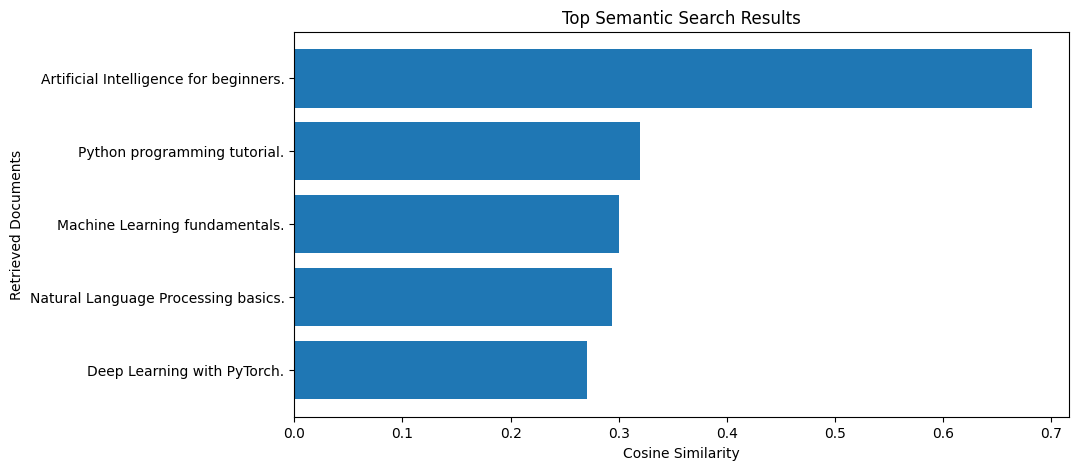

In [9]:
top_results = results.copy()

plt.figure(figsize=(10, 5))

plt.barh(top_results["Document"], top_results["Similarity"])

plt.xlabel("Cosine Similarity")
plt.ylabel("Retrieved Documents")
plt.title("Top Semantic Search Results")

plt.gca().invert_yaxis()

plt.show()

In [10]:
similarity_matrix = cosine_similarity(document_embeddings, document_embeddings)

similarity_df = pd.DataFrame(
    similarity_matrix,
    columns=[f"D{i+1}" for i in range(len(documents))],
    index=[f"D{i+1}" for i in range(len(documents))],
)

similarity_df.round(2)

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10
D1,1.00,0.48,0.38,0.54,0.47,0.19,0.10,0.33,0.33,0.33
D2,0.48,1.00,0.43,0.44,0.27,0.11,0.07,0.42,0.38,0.31
D3,0.38,0.43,1.00,0.27,0.24,0.08,0.01,0.16,0.55,0.08
D4,0.54,0.44,0.27,1.00,0.41,0.04,0.02,0.42,0.21,0.32
D5,0.47,0.27,0.24,0.41,1.00,0.15,-0.02,0.29,0.09,0.22
D6,0.19,0.11,0.08,0.04,0.15,1.00,0.08,0.01,0.06,0.05
D7,0.10,0.07,0.01,0.02,-0.02,0.08,1.00,0.12,0.09,0.12
D8,0.33,0.42,0.16,0.42,0.29,0.01,0.12,1.00,0.16,0.38
D9,0.33,0.38,0.55,0.21,0.09,0.06,0.09,0.16,1.00,0.12
D10,0.33,0.31,0.08,0.32,0.22,0.05,0.12,0.38,0.12,1.00


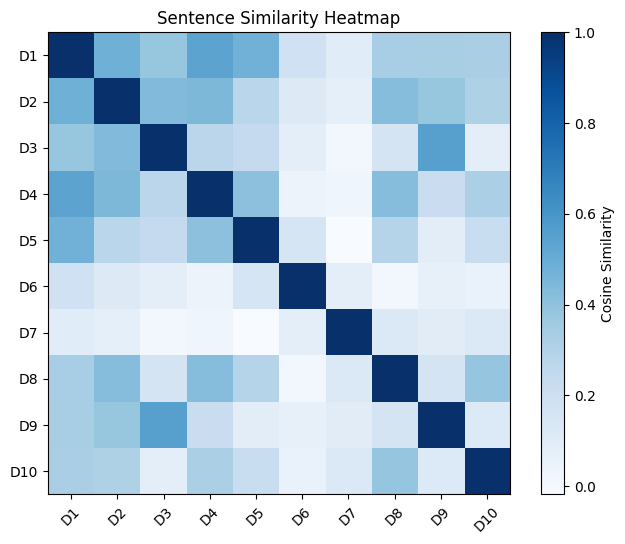

In [11]:
plt.figure(figsize=(8, 6))

plt.imshow(similarity_matrix, cmap="Blues")

plt.colorbar(label="Cosine Similarity")

plt.xticks(
    range(len(documents)), [f"D{i+1}" for i in range(len(documents))], rotation=45
)

plt.yticks(range(len(documents)), [f"D{i+1}" for i in range(len(documents))])

plt.title("Sentence Similarity Heatmap")

plt.show()

In [12]:
while True:

    user_query = input("\nEnter your query (or type 'quit'): ")

    if user_query.lower() == "quit":
        break

    output = semantic_search(
        query=user_query,
        documents=documents,
        document_embeddings=document_embeddings,
        model=model,
        top_k=5,
    )

    print("\nTop Matching Documents:\n")
    print(output)


Top Matching Documents:

                                 Document  Similarity
2             Deep Learning with PyTorch.    0.476341
0  Artificial Intelligence for beginners.    0.403773
8    Computer Vision using Deep Learning.    0.397951
1          Machine Learning fundamentals.    0.288878
3     Natural Language Processing basics.    0.254582


In [14]:
matrix = similarity_matrix.copy()

np.fill_diagonal(matrix, -1)

row, col = np.unravel_index(np.argmax(matrix), matrix.shape)

print("Most Similar Pair:\n")

print(documents[row])

print(documents[col])

print("\nSimilarity Score:", round(matrix[row, col], 3))

Most Similar Pair:

Deep Learning with PyTorch.
Computer Vision using Deep Learning.

Similarity Score: 0.551


In [15]:
selected_doc = 1

scores = similarity_matrix[selected_doc]

recommendation_df = pd.DataFrame({"Document": documents, "Similarity": scores})

recommendation_df = recommendation_df.sort_values(by="Similarity", ascending=False)

recommendation_df.head(5)

,Document,Similarity
1,Machine Learning fundamentals.,1.000000
0,Artificial Intelligence for beginners.,0.482089
3,Natural Language Processing basics.,0.444829
2,Deep Learning with PyTorch.,0.433360
7,Introduction to Data Science.,0.419372
